# Parte 2 — Pipeline de Modelado y Seguimiento de Experimentos
## Predicción de Deserción Estudiantil — SENA Centro Amazonas

**Equipo:** Yeison Acero · Michael Cardenas  
**Dataset:** Fichas de formación Sofia Plus (153 fichas × 38 variables)  
**Problema:** Clasificación binaria (alta/baja deserción) + Regresión continua (tasa de deserción)

---

### Objetivos
1. Entrenar y comparar 3 modelos por cada tarea (clasificación y regresión)
2. Registrar todos los experimentos en MLflow (hiperparámetros, métricas, artefactos)
3. Aplicar optimización de hiperparámetros (GridSearchCV y RandomizedSearchCV)
4. Seleccionar el mejor modelo con justificación basada en métricas y contexto
5. Exportar los modelos seleccionados para despliegue en API REST

In [21]:
# Instalar dependencias si es necesario
# !pip install -r ../requirements.txt

## 1. Configuración e Importaciones

In [32]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import mlflow
import mlflow.sklearn
import mlflow.xgboost

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score,
    classification_report, confusion_matrix,
    mean_squared_error, mean_absolute_error, r2_score
)
import xgboost as xgb

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


In [33]:
# ── Constantes del proyecto ──────────────────────────────────────────────────
RANDOM_STATE        = 42
TEST_SIZE           = 0.20
THRESHOLD_DESERCION = 0.30   # Fichas con >30 % de deserción → clase 1 (ALTA)

FEATURES = [
    'NIVEL_FORMACION', 'JORNADA', 'TRIMESTRE_APERTURA',
    'AÑO_APERTURA', 'CUPO', 'DURACION_MAXIMA',
    'OCUPACION_CUPO', 'PROGRAMA_ESPECIAL'
]
CATEGORICAL_FEATURES = ['NIVEL_FORMACION', 'JORNADA', 'PROGRAMA_ESPECIAL']
NUMERICAL_FEATURES   = ['TRIMESTRE_APERTURA', 'AÑO_APERTURA', 'CUPO',
                         'DURACION_MAXIMA', 'OCUPACION_CUPO']

MLFLOW_TRACKING_URI = "../mlruns"
MODELS_OUTPUT_DIR   = "../api/models"

os.makedirs(MODELS_OUTPUT_DIR, exist_ok=True)
print(f"Umbral clasificación: TASA_DESERCION > {THRESHOLD_DESERCION}")
print(f"Features seleccionadas: {FEATURES}")

Umbral clasificación: TASA_DESERCION > 0.3
Features seleccionadas: ['NIVEL_FORMACION', 'JORNADA', 'TRIMESTRE_APERTURA', 'AÑO_APERTURA', 'CUPO', 'DURACION_MAXIMA', 'OCUPACION_CUPO', 'PROGRAMA_ESPECIAL']


## 2. Carga y Preparación de Datos

In [44]:
df = pd.read_csv('../dataset_formacion_sena.csv', encoding='utf-8-sig')
print(f"Dataset cargado: {df.shape[0]} fichas × {df.shape[1]} variables")
df[FEATURES + ['TASA_DESERCION']].head()

Dataset cargado: 153 fichas × 38 variables


,NIVEL_FORMACION,JORNADA,TRIMESTRE_APERTURA,AÑO_APERTURA,CUPO,DURACION_MAXIMA,OCUPACION_CUPO,PROGRAMA_ESPECIAL,TASA_DESERCION
0,OPERARIO,NOCTURNA,3,2023,35,1296,0.6286,NO,0.6818
1,OPERARIO,NOCTURNA,4,2024,40,1296,0.6500,NO,0.6538
2,OPERARIO,NOCTURNA,4,2025,30,1296,0.8667,NO,0.3077
3,OPERARIO,NOCTURNA,2,2025,25,880,0.7200,AULAS ABIERTAS,0.0556
4,OPERARIO,DIURNA,2,2025,30,1296,0.8000,ATENCION A INSTITUCIONES,0.5000


In [45]:
# Crear variable objetivo binaria
df['DESERCION_ALTA'] = (df['TASA_DESERCION'] > THRESHOLD_DESERCION).astype(int)

X     = df[FEATURES].copy()
y_clf = df['DESERCION_ALTA'].copy()         # target clasificación
y_reg = df['TASA_DESERCION'].copy()         # target regresión

print("\n── Distribución del target de clasificación ──")
dist = y_clf.value_counts(normalize=True).rename({0: 'Baja deserción (0)', 1: 'Alta deserción (1)'})
print(dist.round(3).to_string())
print(f"\n── Estadísticas TASA_DESERCION ──")
print(y_reg.describe().round(3).to_string())


── Distribución del target de clasificación ──
DESERCION_ALTA
Baja deserción (0)    0.667
Alta deserción (1)    0.333

── Estadísticas TASA_DESERCION ──
count    153.000
mean       0.238
std        0.227
min        0.000
25%        0.030
50%        0.222
75%        0.400
max        0.881


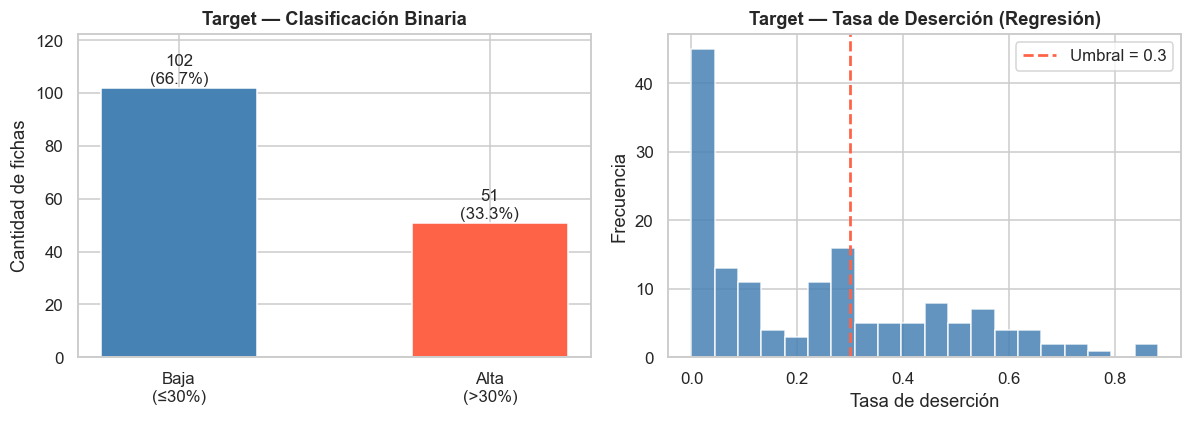

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Distribución binaria
labels = ['Baja\n(≤30%)', 'Alta\n(>30%)']
counts = y_clf.value_counts().sort_index()
axes[0].bar(labels, counts.values, color=['steelblue', 'tomato'], edgecolor='white', width=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 0.5, f'{v}\n({v/len(y_clf):.1%})', ha='center', va='bottom', fontsize=11)
axes[0].set_title('Target — Clasificación Binaria', fontweight='bold')
axes[0].set_ylabel('Cantidad de fichas')
axes[0].set_ylim(0, counts.max() * 1.2)

# Distribución continua
axes[1].hist(y_reg, bins=20, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(THRESHOLD_DESERCION, color='tomato', linestyle='--', linewidth=1.8,
                label=f'Umbral = {THRESHOLD_DESERCION}')
axes[1].set_title('Target — Tasa de Deserción (Regresión)', fontweight='bold')
axes[1].set_xlabel('Tasa de deserción')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.tight_layout()
plt.savefig('../docs/targets_distribucion.png', bbox_inches='tight')
plt.show()

## 3. División de Datos y Pipeline de Preprocesamiento

In [47]:
# División estratificada para preservar balance de clases
X_train, X_test, y_clf_train, y_clf_test, y_reg_train, y_reg_test = train_test_split(
    X, y_clf, y_reg,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_clf
)
print(f"Train: {X_train.shape[0]} muestras  |  Test: {X_test.shape[0]} muestras")
print(f"Balance train — Baja: {(y_clf_train==0).sum()} | Alta: {(y_clf_train==1).sum()}")
print(f"Balance test  — Baja: {(y_clf_test==0).sum()} | Alta: {(y_clf_test==1).sum()}")

Train: 122 muestras  |  Test: 31 muestras
Balance train — Baja: 81 | Alta: 41
Balance test  — Baja: 21 | Alta: 10


In [48]:
# Pipeline de preprocesamiento compartido
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False),
         CATEGORICAL_FEATURES),
        ('num', StandardScaler(), NUMERICAL_FEATURES)
    ],
    remainder='drop'
)

print("Preprocesador configurado:")
print(f"  • Categóricas (OneHotEncoder, drop=first): {CATEGORICAL_FEATURES}")
print(f"  • Numéricas   (StandardScaler):            {NUMERICAL_FEATURES}")

Preprocesador configurado:
  • Categóricas (OneHotEncoder, drop=first): ['NIVEL_FORMACION', 'JORNADA', 'PROGRAMA_ESPECIAL']
  • Numéricas   (StandardScaler):            ['TRIMESTRE_APERTURA', 'AÑO_APERTURA', 'CUPO', 'DURACION_MAXIMA', 'OCUPACION_CUPO']


## 4. Configuración de MLflow

In [49]:
import os
os.environ['MLFLOW_ALLOW_FILE_STORE'] = 'true'

mlflow.set_tracking_uri("file:../mlruns")
print(f"MLflow tracking URI → {mlflow.get_tracking_uri()}")
print("Para visualizar experimentos ejecuta:")
print("  mlflow ui --backend-store-uri file:mlruns  (desde la raíz del proyecto)")

MLflow tracking URI → file:../mlruns
Para visualizar experimentos ejecuta:
  mlflow ui --backend-store-uri file:mlruns  (desde la raíz del proyecto)


In [50]:
# ── Funciones auxiliares de logging ─────────────────────────────────────────

def log_clf_metrics(y_true, y_pred, y_prob):
    """Registra métricas de clasificación en el run activo de MLflow."""
    metrics = {
        'accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'f1'       : round(f1_score(y_true, y_pred, zero_division=0), 4),
        'precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'recall'   : round(recall_score(y_true, y_pred, zero_division=0), 4),
        'roc_auc'  : round(roc_auc_score(y_true, y_prob), 4),
    }
    for name, value in metrics.items():
        mlflow.log_metric(name, value)
    return metrics


def log_reg_metrics(y_true, y_pred):
    """Registra métricas de regresión en el run activo de MLflow."""
    metrics = {
        'rmse': round(np.sqrt(mean_squared_error(y_true, y_pred)), 4),
        'mae' : round(mean_absolute_error(y_true, y_pred), 4),
        'r2'  : round(r2_score(y_true, y_pred), 4),
    }
    for name, value in metrics.items():
        mlflow.log_metric(name, value)
    return metrics


def print_clf_summary(name, metrics, best_params):
    print(f"\n{'─'*55}")
    print(f"  {name}")
    print(f"{'─'*55}")
    for k, v in metrics.items():
        print(f"  {k:<12} {v:.4f}")
    print(f"  Mejores params: {best_params}")


def print_reg_summary(name, metrics, best_params):
    print(f"\n{'─'*55}")
    print(f"  {name}")
    print(f"{'─'*55}")
    for k, v in metrics.items():
        print(f"  {k:<12} {v:.4f}")
    print(f"  Mejores params: {best_params}")


print("Funciones auxiliares definidas.")

Funciones auxiliares definidas.


---
## 5. Experimento 1 — Clasificación de Deserción

**Métrica principal:** Recall clase 1 (Alta deserción)  
**Justificación contextual:** En el contexto educativo del SENA, un **falso negativo** (predecir baja deserción cuando en realidad es alta) es más costoso que un falso positivo. Identificar incorrectamente una ficha de alto riesgo impide que los coordinadores activen protocolos de retención a tiempo. Por esto, priorizamos **recall** sobre accuracy global, complementado con F1 para no perder demasiada precisión.

In [51]:
CLF_RESULTS = []   # Acumular resultados para comparación final

mlflow.set_experiment("Clasificacion_Desercion_SENA")
print("Experimento MLflow: Clasificacion_Desercion_SENA")

2026/06/10 16:29:12 INFO mlflow.tracking.fluent: Experiment with name 'Clasificacion_Desercion_SENA' does not exist. Creating a new experiment.


Experimento MLflow: Clasificacion_Desercion_SENA


### 5.1 Modelo 1 — Regresión Logística (Baseline)

Modelo lineal interpretable. Sirve como **baseline** para evaluar si modelos más complejos aportan valor real. Optimización con **GridSearchCV** (espacio pequeño, búsqueda exhaustiva).

In [52]:
with mlflow.start_run(run_name="LogisticRegression") as run_lr:

    pipeline_lr = Pipeline([
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    ])

    param_grid_lr = {
        'model__C'      : [0.001, 0.01, 0.1, 1, 10, 100],
        'model__penalty': ['l1', 'l2'],
        'model__solver' : ['liblinear', 'saga']
    }

    gs_lr = GridSearchCV(
        pipeline_lr, param_grid_lr,
        cv=5, scoring='recall', n_jobs=-1, verbose=0
    )
    gs_lr.fit(X_train, y_clf_train)

    y_pred_lr = gs_lr.predict(X_test)
    y_prob_lr = gs_lr.predict_proba(X_test)[:, 1]

    # Logging en MLflow
    clean_params = {k.replace('model__', ''): v for k, v in gs_lr.best_params_.items()}
    mlflow.log_params(clean_params)
    mlflow.log_param('optimization', 'GridSearchCV')
    mlflow.log_param('cv_folds', 5)
    mlflow.log_param('scoring', 'recall')

    metrics_lr = log_clf_metrics(y_clf_test, y_pred_lr, y_prob_lr)
    mlflow.sklearn.log_model(gs_lr.best_estimator_, 'model')

    CLF_RESULTS.append({
        'Modelo': 'Logistic Regression',
        'run_id': run_lr.info.run_id,
        'modelo_obj': gs_lr.best_estimator_,
        **metrics_lr
    })
    print_clf_summary('Logistic Regression', metrics_lr, clean_params)
    print(f"\nReporte detallado:\n{classification_report(y_clf_test, y_pred_lr, target_names=['Baja','Alta'])}")

2026/06/10 16:29:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/10 16:29:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



───────────────────────────────────────────────────────
  Logistic Regression
───────────────────────────────────────────────────────
  accuracy     0.6774
  f1           0.5000
  precision    0.5000
  recall       0.5000
  roc_auc      0.7714
  Mejores params: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}

Reporte detallado:
              precision    recall  f1-score   support

        Baja       0.76      0.76      0.76        21
        Alta       0.50      0.50      0.50        10

    accuracy                           0.68        31
   macro avg       0.63      0.63      0.63        31
weighted avg       0.68      0.68      0.68        31



### 5.2 Modelo 2 — Random Forest Classifier

Ensemble de árboles que captura relaciones no lineales. Optimización con **RandomizedSearchCV** (espacio de búsqueda más grande, muestreo aleatorio eficiente).

In [ ]:
with mlflow.start_run(run_name="RandomForestClassifier") as run_rf:

    pipeline_rfc = Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(random_state=RANDOM_STATE))
    ])

    param_dist_rfc = {
        'model__n_estimators'     : [50, 100, 200, 300],
        'model__max_depth'        : [3, 5, 8, 12, None],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf' : [1, 2, 4],
        'model__max_features'     : ['sqrt', 'log2', None],
        'model__class_weight'     : ['balanced', None]
    }

    rs_rfc = RandomizedSearchCV(
        pipeline_rfc, param_dist_rfc,
        n_iter=40, cv=5, scoring='recall',
        random_state=RANDOM_STATE, n_jobs=-1, verbose=0
    )
    rs_rfc.fit(X_train, y_clf_train)

    y_pred_rfc = rs_rfc.predict(X_test)
    y_prob_rfc = rs_rfc.predict_proba(X_test)[:, 1]

    clean_params = {k.replace('model__', ''): v for k, v in rs_rfc.best_params_.items()}
    mlflow.log_params(clean_params)
    mlflow.log_param('optimization', 'RandomizedSearchCV')
    mlflow.log_param('n_iter', 40)
    mlflow.log_param('cv_folds', 5)
    mlflow.log_param('scoring', 'recall')

    metrics_rfc = log_clf_metrics(y_clf_test, y_pred_rfc, y_prob_rfc)
    mlflow.sklearn.log_model(rs_rfc.best_estimator_, 'model')

    CLF_RESULTS.append({
        'Modelo': 'Random Forest',
        'run_id': run_rf.info.run_id,
        'modelo_obj': rs_rfc.best_estimator_,
        **metrics_rfc
    })
    print_clf_summary('Random Forest Classifier', metrics_rfc, clean_params)
    print(f"\nReporte detallado:\n{classification_report(y_clf_test, y_pred_rfc, target_names=['Baja','Alta'])}")

### 5.3 Modelo 3 — XGBoost Classifier

Gradient Boosting optimizado. Generalmente supera a Random Forest en datasets tabulares pequeños. Optimización con **RandomizedSearchCV** sobre un espacio amplio de hiperparámetros.

In [ ]:
with mlflow.start_run(run_name="XGBoostClassifier") as run_xgb:

    # scale_pos_weight compensa el desbalance leve (66/34)
    neg_pos_ratio = (y_clf_train == 0).sum() / (y_clf_train == 1).sum()

    pipeline_xgbc = Pipeline([
        ('preprocessor', preprocessor),
        ('model', xgb.XGBClassifier(
            eval_metric='logloss',
            scale_pos_weight=neg_pos_ratio,
            random_state=RANDOM_STATE,
            verbosity=0
        ))
    ])

    param_dist_xgbc = {
        'model__n_estimators' : [100, 200, 300, 500],
        'model__max_depth'    : [3, 4, 5, 6, 8],
        'model__learning_rate': [0.005, 0.01, 0.05, 0.1, 0.2],
        'model__subsample'    : [0.6, 0.7, 0.8, 0.9, 1.0],
        'model__colsample_bytree': [0.6, 0.7, 0.8, 1.0],
        'model__reg_alpha'    : [0, 0.01, 0.1, 1],
        'model__reg_lambda'   : [0.5, 1, 2, 5]
    }

    rs_xgbc = RandomizedSearchCV(
        pipeline_xgbc, param_dist_xgbc,
        n_iter=50, cv=5, scoring='recall',
        random_state=RANDOM_STATE, n_jobs=-1, verbose=0
    )
    rs_xgbc.fit(X_train, y_clf_train)

    y_pred_xgbc = rs_xgbc.predict(X_test)
    y_prob_xgbc = rs_xgbc.predict_proba(X_test)[:, 1]

    clean_params = {k.replace('model__', ''): v for k, v in rs_xgbc.best_params_.items()}
    clean_params['scale_pos_weight'] = round(neg_pos_ratio, 3)
    mlflow.log_params(clean_params)
    mlflow.log_param('optimization', 'RandomizedSearchCV')
    mlflow.log_param('n_iter', 50)
    mlflow.log_param('cv_folds', 5)
    mlflow.log_param('scoring', 'recall')

    metrics_xgbc = log_clf_metrics(y_clf_test, y_pred_xgbc, y_prob_xgbc)
    mlflow.sklearn.log_model(rs_xgbc.best_estimator_, 'model')

    CLF_RESULTS.append({
        'Modelo': 'XGBoost',
        'run_id': run_xgb.info.run_id,
        'modelo_obj': rs_xgbc.best_estimator_,
        **metrics_xgbc
    })
    print_clf_summary('XGBoost Classifier', metrics_xgbc, clean_params)
    print(f"\nReporte detallado:\n{classification_report(y_clf_test, y_pred_xgbc, target_names=['Baja','Alta'])}")

### 5.4 Comparación de Modelos — Clasificación

In [ ]:
clf_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ('run_id', 'modelo_obj')}
    for r in CLF_RESULTS
]).set_index('Modelo')

print("\n══ Comparación de modelos de clasificación ══")
print(clf_df.round(4).to_string())

# Resaltar mejor modelo por recall
best_clf_name = clf_df['recall'].idxmax()
print(f"\n✓ Mejor recall (clase Alta): {best_clf_name} — {clf_df.loc[best_clf_name, 'recall']:.4f}")

In [ ]:
metrics_to_plot = ['accuracy', 'f1', 'precision', 'recall', 'roc_auc']
x = np.arange(len(metrics_to_plot))
width = 0.25
colors = ['steelblue', 'seagreen', 'tomato']

fig, ax = plt.subplots(figsize=(11, 5))
for i, (_, row) in enumerate(clf_df.iterrows()):
    vals = [row[m] for m in metrics_to_plot]
    bars = ax.bar(x + i * width, vals, width, label=row.name, color=colors[i], alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels([m.upper() for m in metrics_to_plot])
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Comparación de Modelos — Clasificación de Deserción SENA', fontweight='bold')
ax.legend(loc='upper right')
ax.axhline(0.8, color='gray', linestyle=':', alpha=0.6, linewidth=1)

plt.tight_layout()
plt.savefig('../docs/comparacion_clasificacion.png', bbox_inches='tight')
plt.show()

In [ ]:
# Matriz de confusión del mejor modelo de clasificación
best_clf_result = next(r for r in CLF_RESULTS if r['Modelo'] == best_clf_name)
best_clf_model  = best_clf_result['modelo_obj']

y_pred_best_clf = best_clf_model.predict(X_test)
cm = confusion_matrix(y_clf_test, y_pred_best_clf)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred. Baja', 'Pred. Alta'],
            yticklabels=['Real Baja', 'Real Alta'], ax=ax)
ax.set_title(f'Matriz de Confusión — {best_clf_name}', fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/confusion_matrix_clf.png', bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Verdaderos Positivos (Alta correcta):   {tp}")
print(f"Falsos Negativos   (Alta predicha Baja): {fn}  ← minimizar en contexto SENA")
print(f"Falsos Positivos   (Baja predicha Alta): {fp}")
print(f"Verdaderos Negativos (Baja correcta):   {tn}")

---
## 6. Experimento 2 — Regresión de Tasa de Deserción

**Métrica principal:** RMSE (penaliza errores grandes) complementado con MAE y R²  
**Objetivo:** Estimar con precisión la tasa continua de deserción para orientar la magnitud de las intervenciones.

In [ ]:
REG_RESULTS = []

mlflow.set_experiment("Regresion_Desercion_SENA")
print("Experimento MLflow: Regresion_Desercion_SENA")

### 6.1 Modelo 1 — Ridge Regression (Baseline)

In [ ]:
with mlflow.start_run(run_name="RidgeRegression") as run_ridge:

    pipeline_ridge = Pipeline([
        ('preprocessor', preprocessor),
        ('model', Ridge())
    ])

    param_grid_ridge = {
        'model__alpha': [0.001, 0.01, 0.1, 1, 10, 50, 100, 500]
    }

    gs_ridge = GridSearchCV(
        pipeline_ridge, param_grid_ridge,
        cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=0
    )
    gs_ridge.fit(X_train, y_reg_train)

    y_pred_ridge = gs_ridge.predict(X_test)
    # Clampear predicciones al rango válido [0, 1]
    y_pred_ridge = np.clip(y_pred_ridge, 0, 1)

    clean_params = {k.replace('model__', ''): v for k, v in gs_ridge.best_params_.items()}
    mlflow.log_params(clean_params)
    mlflow.log_param('optimization', 'GridSearchCV')
    mlflow.log_param('cv_folds', 5)
    mlflow.log_param('scoring', 'neg_root_mean_squared_error')

    metrics_ridge = log_reg_metrics(y_reg_test, y_pred_ridge)
    mlflow.sklearn.log_model(gs_ridge.best_estimator_, 'model')

    REG_RESULTS.append({
        'Modelo': 'Ridge Regression',
        'run_id': run_ridge.info.run_id,
        'modelo_obj': gs_ridge.best_estimator_,
        **metrics_ridge
    })
    print_reg_summary('Ridge Regression', metrics_ridge, clean_params)

### 6.2 Modelo 2 — Random Forest Regressor

In [ ]:
with mlflow.start_run(run_name="RandomForestRegressor") as run_rfr:

    pipeline_rfr = Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(random_state=RANDOM_STATE))
    ])

    param_dist_rfr = {
        'model__n_estimators'     : [50, 100, 200, 300],
        'model__max_depth'        : [3, 5, 8, 12, None],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf' : [1, 2, 4],
        'model__max_features'     : ['sqrt', 'log2', None]
    }

    rs_rfr = RandomizedSearchCV(
        pipeline_rfr, param_dist_rfr,
        n_iter=40, cv=5, scoring='neg_root_mean_squared_error',
        random_state=RANDOM_STATE, n_jobs=-1, verbose=0
    )
    rs_rfr.fit(X_train, y_reg_train)

    y_pred_rfr = np.clip(rs_rfr.predict(X_test), 0, 1)

    clean_params = {k.replace('model__', ''): v for k, v in rs_rfr.best_params_.items()}
    mlflow.log_params(clean_params)
    mlflow.log_param('optimization', 'RandomizedSearchCV')
    mlflow.log_param('n_iter', 40)
    mlflow.log_param('cv_folds', 5)
    mlflow.log_param('scoring', 'neg_root_mean_squared_error')

    metrics_rfr = log_reg_metrics(y_reg_test, y_pred_rfr)
    mlflow.sklearn.log_model(rs_rfr.best_estimator_, 'model')

    REG_RESULTS.append({
        'Modelo': 'Random Forest',
        'run_id': run_rfr.info.run_id,
        'modelo_obj': rs_rfr.best_estimator_,
        **metrics_rfr
    })
    print_reg_summary('Random Forest Regressor', metrics_rfr, clean_params)

### 6.3 Modelo 3 — XGBoost Regressor

In [ ]:
with mlflow.start_run(run_name="XGBoostRegressor") as run_xgbr:

    pipeline_xgbr = Pipeline([
        ('preprocessor', preprocessor),
        ('model', xgb.XGBRegressor(
            objective='reg:squarederror',
            random_state=RANDOM_STATE,
            verbosity=0
        ))
    ])

    param_dist_xgbr = {
        'model__n_estimators' : [100, 200, 300, 500],
        'model__max_depth'    : [3, 4, 5, 6, 8],
        'model__learning_rate': [0.005, 0.01, 0.05, 0.1, 0.2],
        'model__subsample'    : [0.6, 0.7, 0.8, 0.9, 1.0],
        'model__colsample_bytree': [0.6, 0.7, 0.8, 1.0],
        'model__reg_alpha'    : [0, 0.01, 0.1, 1],
        'model__reg_lambda'   : [0.5, 1, 2, 5]
    }

    rs_xgbr = RandomizedSearchCV(
        pipeline_xgbr, param_dist_xgbr,
        n_iter=50, cv=5, scoring='neg_root_mean_squared_error',
        random_state=RANDOM_STATE, n_jobs=-1, verbose=0
    )
    rs_xgbr.fit(X_train, y_reg_train)

    y_pred_xgbr = np.clip(rs_xgbr.predict(X_test), 0, 1)

    clean_params = {k.replace('model__', ''): v for k, v in rs_xgbr.best_params_.items()}
    mlflow.log_params(clean_params)
    mlflow.log_param('optimization', 'RandomizedSearchCV')
    mlflow.log_param('n_iter', 50)
    mlflow.log_param('cv_folds', 5)
    mlflow.log_param('scoring', 'neg_root_mean_squared_error')

    metrics_xgbr = log_reg_metrics(y_reg_test, y_pred_xgbr)
    mlflow.sklearn.log_model(rs_xgbr.best_estimator_, 'model')

    REG_RESULTS.append({
        'Modelo': 'XGBoost',
        'run_id': run_xgbr.info.run_id,
        'modelo_obj': rs_xgbr.best_estimator_,
        **metrics_xgbr
    })
    print_reg_summary('XGBoost Regressor', metrics_xgbr, clean_params)

### 6.4 Comparación de Modelos — Regresión

In [ ]:
reg_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ('run_id', 'modelo_obj')}
    for r in REG_RESULTS
]).set_index('Modelo')

print("\n══ Comparación de modelos de regresión ══")
print(reg_df.round(4).to_string())

best_reg_name = reg_df['rmse'].idxmin()
print(f"\n✓ Menor RMSE: {best_reg_name} — {reg_df.loc[best_reg_name, 'rmse']:.4f}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# RMSE y MAE — menor es mejor
x = np.arange(3)
width = 0.35
colors = ['steelblue', 'seagreen', 'tomato']
modelos = reg_df.index.tolist()

axes[0].bar(modelos, reg_df['rmse'], color=colors, alpha=0.85, label='RMSE')
for i, v in enumerate(reg_df['rmse']):
    axes[0].text(i, v + 0.003, f'{v:.4f}', ha='center', va='bottom', fontsize=9)
axes[0].set_title('RMSE — menor es mejor', fontweight='bold')
axes[0].set_ylabel('RMSE')

axes[1].bar(modelos, reg_df['r2'], color=colors, alpha=0.85)
for i, v in enumerate(reg_df['r2']):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom', fontsize=9)
axes[1].set_title('R² — mayor es mejor', fontweight='bold')
axes[1].set_ylabel('R²')

plt.suptitle('Comparación de Modelos — Regresión Tasa Deserción SENA', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../docs/comparacion_regresion.png', bbox_inches='tight')
plt.show()

---
## 7. Selección del Mejor Modelo y Justificación

### Criterios de selección

| Tarea | Métrica principal | Motivo |
|---|---|---|
| Clasificación | **Recall (clase Alta)** | Minimizar falsos negativos — perder un estudiante en riesgo es el peor error |
| Regresión | **RMSE** | Penaliza errores grandes; una estimación con error de ±5% es aceptable operativamente |

### Contexto operativo
Los coordinadores del SENA usan estas predicciones para priorizar fichas con atención preventiva. Una ficha de *Alta* deserción detectada correctamente activa protocolos de seguimiento. Un fallo (FN) implica que la ficha pasa sin monitoreo adicional y los estudiantes desertan sin intervención.

In [ ]:
print("═" * 60)
print("  SELECCIÓN DE MEJORES MODELOS")
print("═" * 60)

# Clasificación
print("\n── CLASIFICACIÓN ──")
print(clf_df[['recall', 'f1', 'roc_auc', 'accuracy']].round(4).to_string())
print(f"\n→ Modelo seleccionado: {best_clf_name}")
print(f"  Recall  : {clf_df.loc[best_clf_name, 'recall']:.4f}")
print(f"  F1      : {clf_df.loc[best_clf_name, 'f1']:.4f}")
print(f"  ROC-AUC : {clf_df.loc[best_clf_name, 'roc_auc']:.4f}")

# Regresión
print("\n── REGRESIÓN ──")
print(reg_df[['rmse', 'mae', 'r2']].round(4).to_string())
print(f"\n→ Modelo seleccionado: {best_reg_name}")
print(f"  RMSE : {reg_df.loc[best_reg_name, 'rmse']:.4f}")
print(f"  MAE  : {reg_df.loc[best_reg_name, 'mae']:.4f}")
print(f"  R²   : {reg_df.loc[best_reg_name, 'r2']:.4f}")

---
## 8. Exportación de Modelos para Despliegue

In [ ]:
best_clf_obj = next(r['modelo_obj'] for r in CLF_RESULTS if r['Modelo'] == best_clf_name)
best_reg_obj = next(r['modelo_obj'] for r in REG_RESULTS if r['Modelo'] == best_reg_name)

clf_path = os.path.join(MODELS_OUTPUT_DIR, 'mejor_clasificador.pkl')
reg_path = os.path.join(MODELS_OUTPUT_DIR, 'mejor_regresor.pkl')

joblib.dump(best_clf_obj, clf_path)
joblib.dump(best_reg_obj, reg_path)

# Guardar también metadata del modelo
import json
model_meta = {
    'clasificador': {
        'nombre': best_clf_name,
        'path': 'models/mejor_clasificador.pkl',
        'metrica_principal': 'recall',
        'valor_metrica': float(clf_df.loc[best_clf_name, 'recall']),
        'features': FEATURES,
        'threshold': THRESHOLD_DESERCION
    },
    'regresor': {
        'nombre': best_reg_name,
        'path': 'models/mejor_regresor.pkl',
        'metrica_principal': 'rmse',
        'valor_metrica': float(reg_df.loc[best_reg_name, 'rmse']),
        'features': FEATURES
    }
}

with open(os.path.join(MODELS_OUTPUT_DIR, 'model_metadata.json'), 'w', encoding='utf-8') as f:
    json.dump(model_meta, f, ensure_ascii=False, indent=2)

print(f"Modelos exportados:")
print(f"  Clasificador → {clf_path}")
print(f"  Regresor     → {reg_path}")
print(f"  Metadata     → {MODELS_OUTPUT_DIR}/model_metadata.json")
print("\nListo para despliegue con Docker + FastAPI.")